# EDA 05 - Road Closures and Train Station-Day Dataset

**Reads from**:  
- `data/processed/road_closures_clean.parquet` (EDA 02)  
- `data/processed/unplanned_road_closures.parquet` (EDA 02)  
- `data/processed/planned_road_closures.parquet` (EDA 02)  
- `data/processed/train_movements_clean.parquet` (EDA 03)  
- `data/processed/train_station_day.parquet` (EDA 03)  
- `data/processed/stations_reference.parquet` (EDA 01)  
**Output**: `data/processed/road_station_day_dataset.parquet` - primary modelling input for the classification and regression models

This notebook builds the analytical dataset used for modelling. It links road closures to nearby stations via a haversine spatial join, expands closures across active calendar days, aggregates all features to station-day level and joins them to the train movement performance metrics. The result is one row per station per day, with road closure features alongside rail performance targets.

---
**Sections**
0. Setup  
1. Rebuild analytical dataset  
2. Spatial join: link all closures to nearby stations (10-25 km)  
3. Expand closures across active days  
4. Closure-hour tagging (spatial and temporal)  
5. Aggregate closure-hour delay metrics  
6. Aggregate road closures to station-day level  
7. Join train station-day and road features  
8. Merge closure-hour metrics  
9. Temporal and lag features  
10. Dataset summary  
11. EDA: delay distribution  
12. EDA: full correlation matrix  
13. EDA: delay during vs outside closure hours  
14. EDA: disruption rate by road class and closure type  
15. EDA: delay by day of week and closure presence  
16. EDA: top stations by record count  
17. Save final analytical dataset  

## 0. Setup

In [24]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
%matplotlib inline

# Day-of-week label map - defined once and reused across section 9 and 15
DOW_MAP = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Analytical Dataset

Read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps EDA 05 self-contained and fast. No Azure downloads are needed beyond what was already done in the earlier notebooks.

In [25]:
from src.geo import find_nearby_stations

# Road closures
road_df           = pd.read_parquet("./data/processed/road_closures_clean.parquet")
unplanned_road_df = pd.read_parquet("./data/processed/unplanned_road_closures.parquet")

# Train outputs from EDA 03
train_station_day = pd.read_parquet("./data/processed/train_station_day.parquet")
train_movements_df  = pd.read_parquet("./data/processed/train_movements_clean.parquet")

# Station reference for spatial join
stations_ref_df   = pd.read_parquet("./data/processed/stations_reference.parquet")

# EDA 03 groups by loc_stanox; rename to stanox for consistent join keys downstream
if "loc_stanox" in train_station_day.columns and "stanox" not in train_station_day.columns:
    train_station_day["stanox"] = (
        train_station_day["loc_stanox"]
        .astype(float)
        .astype(int)
        .astype(str)
    )
if "loc_stanox" in train_movements_df.columns and "stanox" not in train_movements_df.columns:
    train_movements_df["stanox"] = (
        train_movements_df["loc_stanox"]
        .astype(float)
        .astype(int)
        .astype(str)
    )

# stations_reference uses lowercase column names from EDA 01
# 'station' column holds the human-readable station name
if "station" in stations_ref_df.columns and "station_name" not in stations_ref_df.columns:
    stations_ref_df = stations_ref_df.rename(columns={"station": "station_name"})

print("=== Input Shapes ===")
print(f"Road closures (all):       {len(road_df):,}")
print(f"Road closures (unplanned): {len(unplanned_road_df):,}")
print(f"Train station-day:         {len(train_station_day):,}")
print(f"Train movements (clean):   {len(train_movements_df):,}")
print(f"Stations reference:        {len(stations_ref_df):,}")

print("\n=== Date Alignment Check ===")
print(f"Road closures:    {road_df['effective_start_time'].min()} - {road_df['effective_end_time'].max()}")
train_station_day["planned_date"] = pd.to_datetime(train_station_day["planned_date"])
print(f"Train station-day:{train_station_day['planned_date'].min()} - {train_station_day['planned_date'].max()}")


=== Input Shapes ===
Road closures (all):       1,473
Road closures (unplanned): 1,084
Train station-day:         33,941
Train movements (clean):   212,645
Stations reference:        2,594

=== Date Alignment Check ===
Road closures:    2026-04-10 00:00:00+00:00 - 2026-04-30 23:59:59+00:00
Train station-day:2026-04-03 00:00:00 - 2026-04-28 00:00:00


## 2. Spatial Join: Link All Closures to Nearby Stations (10-25 km)

In [26]:
expanded_road_df = find_nearby_stations(
    road_df, stations_ref_df, min_km=10, max_km=25
)

print(f"Closure-station pairs (all):       {len(expanded_road_df):,}")
print(f"Unique closures matched:           {expanded_road_df['closure_id'].nunique():,}")
print(f"Unique stations with any closure:  {expanded_road_df['station_name'].nunique():,}")
print(f"Unique stations total:             {stations_ref_df['station_name'].nunique():,}")
print(f"Coverage: {expanded_road_df['station_name'].nunique() / stations_ref_df['station_name'].nunique() * 100:.1f}% of stations have at least one nearby closure")

display(expanded_road_df[[
    "closure_id", "station_name", "distance_in_km",
    "closure_type", "road_name", "road_class", "closure_severity",
    "effective_start_time", "effective_end_time","validity_status",
    "effective_duration_hours"
]].head())

Closure-station pairs (all):       95,816
Unique closures matched:           1,277
Unique stations with any closure:  1,775
Unique stations total:             2,594
Coverage: 68.4% of stations have at least one nearby closure


,closure_id,station_name,distance_in_km,closure_type,road_name,road_class,closure_severity,effective_start_time,effective_end_time,validity_status,effective_duration_hours
0,481398,Dullingham,21.561992,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,10.0
1,481398,Ely,21.974512,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,10.0
2,481398,Foxton,13.545760,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,10.0
3,481398,Great Chesterford,22.207451,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,10.0
4,481398,Huntingdon,19.527520,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,10.0


In [27]:
# Spatial join - unplanned closures separately for closure-hour analysis
expanded_unplanned_df = find_nearby_stations(
    unplanned_road_df, stations_ref_df, min_km=10, max_km=25
)

print(f"Closure-station pairs (unplanned): {len(expanded_unplanned_df):,}")
print(f"Unique unplanned closures matched: {expanded_unplanned_df['closure_id'].nunique():,}")
print(f"Unique stations near unplanned:    {expanded_unplanned_df['station_name'].nunique():,}")

Closure-station pairs (unplanned): 80,277
Unique unplanned closures matched: 1,052
Unique stations near unplanned:    1,486


## 3. Expand Closures Across Active Days

In [28]:
def expand_closures_to_days(df):
    """
    Explode each closure across every calendar day it is active.
    A closure running Apr 10-14 becomes 5 rows, one per day.
    This bridges the temporal granularity gap between road closures
    (spanning days) and train movements (per-second).
    """
    df = df.copy()
    df["effective_start_time"] = pd.to_datetime(
        df["effective_start_time"], utc=True, errors="coerce"
    )
    df["effective_end_time"] = pd.to_datetime(
        df["effective_end_time"], utc=True, errors="coerce"
    )
    df = df.dropna(
        subset=["effective_start_time", "effective_end_time", "station_name"]
    )
    df["planned_date"] = df.apply(
        lambda row: pd.date_range(
            row["effective_start_time"].floor("D"),
            row["effective_end_time"].floor("D"),
            freq="D",
        ),
        axis=1,
    )
    df = df.explode("planned_date").copy()
    df["planned_date"] = pd.to_datetime(df["planned_date"]).dt.date
    return df

# Expand all closures for the station-day road feature aggregation (section 6)
road_station_day = expand_closures_to_days(expanded_road_df)

print(f"Road station-day rows (all): {len(road_station_day):,}")
display(road_station_day.head(3))

Road station-day rows (all): 162,779


,closure_id,closure_type,closure_start_time,closure_end_time,road_name,road_class,closure_severity,start_hour,start_dow,start_date,duration_hours,effective_duration_hours,effective_end_time,effective_start_time,validity_status,cause_type,station_name,station_code,stanox,tpl,distance_in_km,planned_date
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-11
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-12
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512,2026-04-11


## 4. Closure-Hour Tagging (Spatial and Temporal)

For each unplanned closure-station pair, filter train movements to those whose `actual_timestamp` falls within the closure's `effective_start_time` and `effective_end_time`. This is the precise window analysis: not just whether a closure was active on a given day, but whether individual trains were moving during the specific hours the closure was active nearby.

In [29]:
# Ensure timestamps are UTC-aware in train moments
train_movements_df["actual_timestamp"] = pd.to_datetime(
    train_movements_df["actual_timestamp"], utc=True, errors="coerce"
)

# Build station-level closure window lookup for unplanned closures
# station_name → list of (start, end, closure_id) tuples
station_closure_windows = (
    expanded_unplanned_df
    .dropna(subset=["effective_start_time", "effective_end_time"])
    .assign(
        effective_start_time=lambda d: pd.to_datetime(
            d["effective_start_time"], utc=True
        ),
        effective_end_time=lambda d: pd.to_datetime(
            d["effective_end_time"], utc=True
        ),
    )
    .groupby("station_name")
    .apply(lambda g: list(zip(
        g["effective_start_time"],
        g["effective_end_time"],
        g["closure_id"]
    )))
    .to_dict()
)

print(f"Stations with unplanned closure windows: {len(station_closure_windows):,}")

def is_during_unplanned_closure(row):
    windows = station_closure_windows.get(row["station_name"], [])
    if not windows or pd.isna(row["actual_timestamp"]):
        return 0
    t = row["actual_timestamp"]
    return int(any(start <= t <= end for start, end, _ in windows))

print("Tagging movements during unplanned closure windows...")
train_movements_df["during_unplanned_closure"] = train_movements_df.apply(
    is_during_unplanned_closure, axis=1
)

n_tagged = train_movements_df["during_unplanned_closure"].sum()
print(f"Movements during unplanned closure: {n_tagged:,} ({n_tagged/len(train_movements_df)*100:.1f}%)")
print(f"Movements outside closure:          {len(train_movements_df) - n_tagged:,}")

Stations with unplanned closure windows: 1,486
Tagging movements during unplanned closure windows...
Movements during unplanned closure: 4,575 (2.2%)
Movements outside closure:          208,070


## 5. Aggregate Closure-Hour Delay Metrics

Aggregate delay metrics for movements that occurred during unplanned closure windows. These become additional model features that directly operationalise the cross-modal hypothesis.

In [30]:
closure_hour_agg = (
    train_movements_df[train_movements_df["during_unplanned_closure"] == 1]
    .dropna(subset=["station_name"])
    .groupby(["station_name", "stanox", "planned_date"], dropna=False)
    .agg(
        movements_during_closure  = ("planned_timestamp", "count"),
        mean_delay_during_closure = ("delay_minutes",     "mean"),
        pct_late_during_closure   = ("is_late",           "mean"),
        max_delay_during_closure  = ("late_minutes",      "max"),
        pct_delayed_5min_during   = ("is_delayed_5min",   "mean"),
    )
    .reset_index()
)

closure_hour_agg["stanox"] = closure_hour_agg["stanox"].apply(
    lambda x: str(int(x)) if pd.notna(x) else None
)
closure_hour_agg["planned_date"] = pd.to_datetime(closure_hour_agg["planned_date"])

print(f"Station-days with movements during unplanned closures: {len(closure_hour_agg):,}")
print(f"Unique stations:                                       {closure_hour_agg['station_name'].nunique():,}")
display(closure_hour_agg.head(3))

Station-days with movements during unplanned closures: 2,877
Unique stations:                                       947


,station_name,stanox,planned_date,movements_during_closure,mean_delay_during_closure,pct_late_during_closure,max_delay_during_closure,pct_delayed_5min_during
0,Abbey Wood,88601,2026-04-16,1,0.0,0.0,0.0,0.0
1,Abbey Wood,88601,2026-04-23,1,1.0,1.0,1.0,0.0
2,Abbey Wood,88601,2026-04-27,1,1.5,1.0,1.5,0.0


## 6. Aggregate Road Closures to Station-Day Level

In [31]:
road_station_day_agg = (
    road_station_day
    .groupby(["station_name", "stanox", "planned_date"], dropna=False)
    .agg(
        road_closure_count            = ("closure_id",               "nunique"),
        min_distance_km               = ("distance_in_km",           "min"),
        mean_distance_km              = ("distance_in_km",           "mean"),
        max_effective_duration_hours  = ("effective_duration_hours", "max"),
        mean_effective_duration_hours = ("effective_duration_hours", "mean"),
        # Closer closures contribute more signal
        inv_distance_sum              = ("distance_in_km",           lambda x: (1 / x).sum()),
        # Road-class-weighted severity (weights applied in EDA 02 classify_road)
        total_closure_severity        = ("closure_severity",         "sum"),
        max_road_class                = ("road_class",               "max"),
    )
    .reset_index()
)

# Unplanned closure count as a separate column
n_unplanned = (
    road_station_day[road_station_day["closure_type"] == "unplanned"]
    .groupby(["station_name", "stanox", "planned_date"])["closure_id"]
    .nunique()
    .reset_index(name="n_unplanned_closures")
)
road_station_day_agg = road_station_day_agg.merge(
    n_unplanned, on=["station_name", "stanox", "planned_date"], how="left"
)
road_station_day_agg["n_unplanned_closures"] = (
    road_station_day_agg["n_unplanned_closures"].fillna(0).astype(int)
)
road_station_day_agg["has_road_closure"] = (
    road_station_day_agg["road_closure_count"] > 0
).astype(int)

road_station_day_agg["planned_date"] = pd.to_datetime(road_station_day_agg["planned_date"])

print(f"Aggregated road station-day rows: {len(road_station_day_agg):,}")
display(road_station_day_agg.head(3))

Aggregated road station-day rows: 29,553


,station_name,stanox,planned_date,road_closure_count,min_distance_km,mean_distance_km,max_effective_duration_hours,mean_effective_duration_hours,inv_distance_sum,total_closure_severity,max_road_class,n_unplanned_closures,has_road_closure
0,Abbey Wood,88601,2026-04-10,7,10.191189,18.115876,6.5,2.357143,0.414091,49.50,3,4,1
1,Abbey Wood,88601,2026-04-11,3,13.397358,18.104797,8.0,4.916667,0.176387,44.25,3,1,1
2,Abbey Wood,88601,2026-04-12,3,11.301188,17.208552,8.0,5.791667,0.381811,91.25,3,1,1


## 7. Join Train Station-Day and Road Features

Left join preserves station-days with no nearby closures as negative examples. Without these, the classifier cannot learn what normal performance looks like.

In [32]:
# train_station_day has stanox (renamed from loc_stanox in section 1).
# planned_date is cast to datetime for a clean join.
train_station_day["planned_date"] = pd.to_datetime(train_station_day["planned_date"])

station_day_df = train_station_day.merge(
    road_station_day_agg,
    on=["station_name", "stanox", "planned_date"],
    how="left"
)

ROAD_COLS = [
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "mean_distance_km",
    "max_effective_duration_hours", "mean_effective_duration_hours",
    "inv_distance_sum", "total_closure_severity",
    "max_road_class", "has_road_closure",
]
for col in ROAD_COLS:
    if col in station_day_df.columns:
        station_day_df[col] = station_day_df[col].fillna(0)

print(f"Merged dataset shape: {station_day_df.shape}")
print(f"Rows with closure:    {station_day_df['has_road_closure'].sum():,} ({station_day_df['has_road_closure'].mean()*100:.1f}%)")
print(f"Rows without closure: {(station_day_df['has_road_closure'] == 0).sum():,} ({(1 - station_day_df['has_road_closure'].mean())*100:.1f}%)")

Merged dataset shape: (33941, 23)
Rows with closure:    20,009.0 (59.0%)
Rows without closure: 13,932 (41.0%)


## 8. Merge Closure-Hour Metrics

In [ ]:
# Bring in closure-hour delay metrics as additional model features
station_day_df = station_day_df.merge(
    closure_hour_agg[[
        "station_name", "stanox", "planned_date",
        "movements_during_closure",
        "mean_delay_during_closure",
        "pct_late_during_closure",
        "max_delay_during_closure",
        "pct_delayed_5min_during",
    ]],
    on=["station_name", "stanox", "planned_date"],
    how="left"
)

CLOSURE_HOUR_COLS = [
    "movements_during_closure", "mean_delay_during_closure",
    "pct_late_during_closure", "max_delay_during_closure",
    "pct_delayed_5min_during",
]
for col in CLOSURE_HOUR_COLS:
    station_day_df[col] = station_day_df[col].fillna(0)

print(f"Station-days with closure-hour metrics: "
      f"{(station_day_df['movements_during_closure'] > 0).sum():,}")
display(station_day_df[CLOSURE_HOUR_COLS].describe().round(3))

Station-days with closure-hour metrics: 2,877


,movements_during_closure,mean_delay_during_closure,pct_late_during_closure,max_delay_during_closure,pct_delayed_5min_during
count,33941.000,33941.000,33941.000,33941.000,33941.000
mean,0.135,0.092,0.038,0.176,0.007
std,0.563,1.025,0.183,1.293,0.077
min,0.000,-8.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.000,0.000,0.000
max,15.000,22.500,1.000,22.500,1.000


## 9. Temporal and Lag Features

In [34]:
station_day_df["day_of_week"] = station_day_df["planned_date"].dt.dayofweek
station_day_df["is_weekend"]  = station_day_df["day_of_week"].isin([5, 6]).astype(int)
station_day_df["is_monday"]   = (station_day_df["day_of_week"] == 0).astype(int)
station_day_df["is_friday"]   = (station_day_df["day_of_week"] == 4).astype(int)

print("Disruption rate by day of week:")
dow = (
    station_day_df
    .groupby("day_of_week")["mean_delay_minutes"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_delay", "count": "n_days"})
)
dow.index = [DOW_MAP[i] for i in dow.index]
display(dow.round(3))


Disruption rate by day of week:


,mean_delay,n_days
Mon,0.957,6322
Tue,0.752,6029
Wed,0.720,1976
Thu,0.904,4276
Fri,1.351,6070
Sat,0.546,3639
Sun,0.922,5629


### Lag Features

Rolling closure counts from previous days at the same station give the model temporal memory, capturing sustained road pressure rather than isolated one-off events.

In [35]:
station_day_df = station_day_df.sort_values(
    ["station_name", "planned_date"]
).reset_index(drop=True)

for window in [1, 3, 7]:
    station_day_df[f"closures_lag{window}d"] = (
        station_day_df
        .groupby("station_name")["road_closure_count"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
        .fillna(0)
    )

print("Lag features added:")
print(station_day_df[[
    "station_name", "planned_date", "road_closure_count",
    "closures_lag1d", "closures_lag3d", "closures_lag7d"
]].head(8).to_string())

Lag features added:
  station_name planned_date  road_closure_count  closures_lag1d  closures_lag3d  closures_lag7d
0   Abbey Wood   2026-04-10                 7.0             0.0             0.0             0.0
1   Abbey Wood   2026-04-11                 3.0             7.0             7.0             7.0
2   Abbey Wood   2026-04-12                 3.0             3.0            10.0            10.0
3   Abbey Wood   2026-04-13                 3.0             3.0            13.0            13.0
4   Abbey Wood   2026-04-14                 3.0             3.0             9.0            16.0
5   Abbey Wood   2026-04-15                 2.0             3.0             9.0            19.0
6   Abbey Wood   2026-04-16                 6.0             2.0             8.0            21.0
7   Abbey Wood   2026-04-17                 3.0             6.0            11.0            27.0


## 10. Dataset Summary

In [36]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Total rows:              {len(station_day_df):,}")
print(f"Unique stations:         {station_day_df['station_name'].nunique():,}")
print(f"Date range:              {station_day_df['planned_date'].min().date()} to {station_day_df['planned_date'].max().date()}")
print(f"With any closure:        {station_day_df['has_road_closure'].sum():,} ({station_day_df['has_road_closure'].mean()*100:.1f}%)")
print(f"With unplanned closure:  {(station_day_df['n_unplanned_closures'] > 0).sum():,} ({(station_day_df['n_unplanned_closures'] > 0).mean()*100:.1f}%)")
print(f"With closure-hour data:  {(station_day_df['movements_during_closure'] > 0).sum():,}")
print()

# New EDA 03 columns available in the joined dataset
new_cols = [c for c in ["median_delay_minutes", "late_share", "delayed_5min_share",
                         "severe_15min_share", "peak_movement_share", "station_disrupted"]
            if c in station_day_df.columns]
if new_cols:
    print(f"EDA 03 columns present: {new_cols}")
    print()

dupes = (
    station_day_df
    .groupby(["station_name", "stanox", "planned_date"])
    .size()
    .pipe(lambda s: s[s > 1])
)
print(f"Duplicate station-day rows: {len(dupes):,}")

FINAL DATASET SUMMARY
Total rows:              33,941
Unique stations:         2,506
Date range:              2026-04-03 to 2026-04-28
With any closure:        20,009.0 (59.0%)
With unplanned closure:  15,040 (44.3%)
With closure-hour data:  2,877

EDA 03 columns present: ['median_delay_minutes', 'late_share', 'delayed_5min_share', 'severe_15min_share', 'peak_movement_share', 'station_disrupted']

Duplicate station-day rows: 0


## 11. EDA: Delay Distribution
### Mean


Delay statistics (minutes):
count    33941.000
mean         0.921
std          2.634
min         -8.000
25%         -0.375
50%          0.300
75%          1.500
max         22.500
Name: mean_delay_minutes, dtype: float64

Skewness: 2.945   Kurtosis: 16.980

Quantiles:
0.01    -4.00
0.05    -1.25
0.25    -0.38
0.50     0.30
0.75     1.50
0.95     5.50
0.99    11.50
Name: mean_delay_minutes, dtype: float64


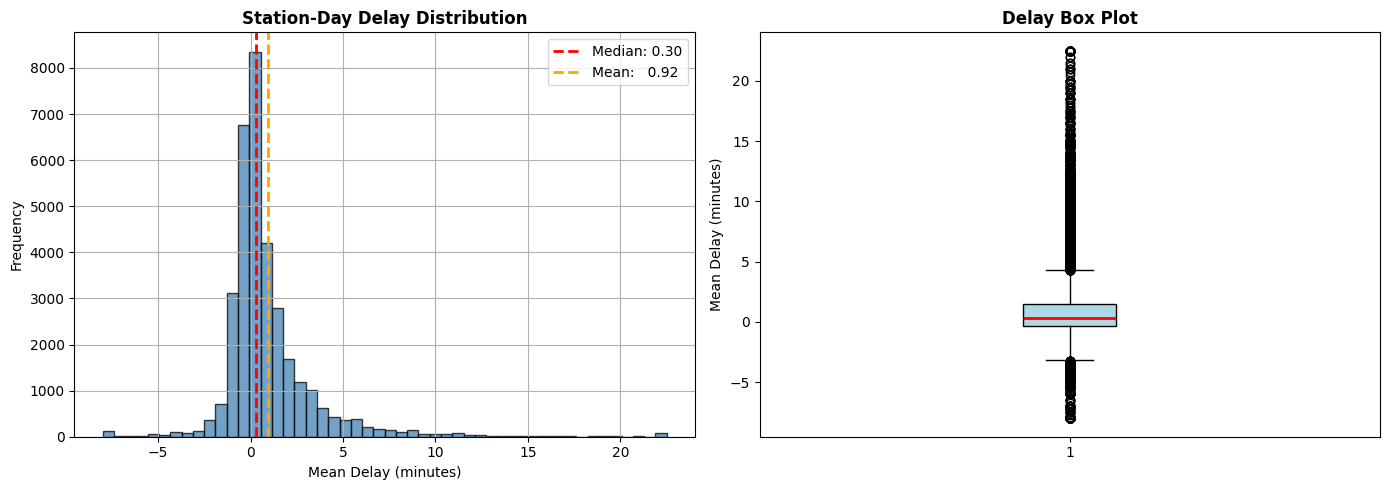

In [37]:
delay = station_day_df["mean_delay_minutes"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")
print(f"\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Mean:   {delay.mean():.2f}")
axes[0].set_xlabel("Mean Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Station-Day Delay Distribution", fontweight="bold")
axes[0].legend()

axes[1].boxplot(delay.dropna(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_title("Delay Box Plot", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05/mean_delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

### Median

Delay statistics (minutes):
count    33941.000
mean         0.542
std          2.513
min         -8.000
25%         -0.500
50%          0.000
75%          0.750
max         22.500
Name: median_delay_minutes, dtype: float64

Skewness: 3.871   Kurtosis: 25.844

Quantiles:
0.01    -4.00
0.05    -1.00
0.25    -0.50
0.50     0.00
0.75     0.75
0.95     4.25
0.99    11.50
Name: median_delay_minutes, dtype: float64


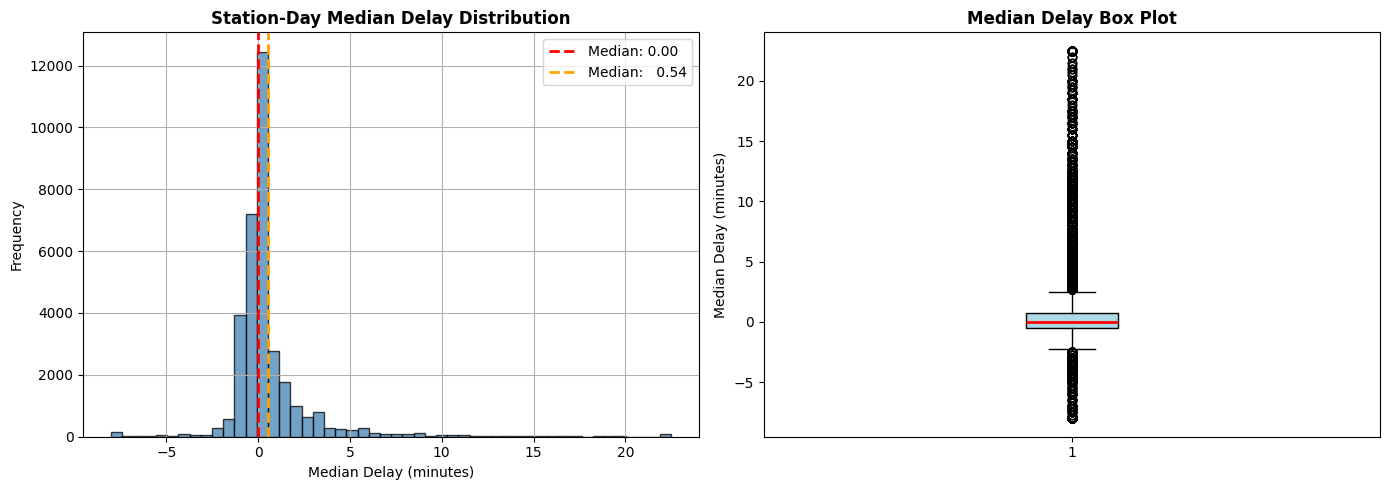

In [38]:
delay = station_day_df["median_delay_minutes"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")
print(f"\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Median:   {delay.mean():.2f}")
axes[0].set_xlabel("Median Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Station-Day Median Delay Distribution", fontweight="bold")
axes[0].legend()

axes[1].boxplot(delay.dropna(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Median Delay (minutes)")
axes[1].set_title("Median Delay Box Plot", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05/median_delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. EDA: Full Correlation Matrix

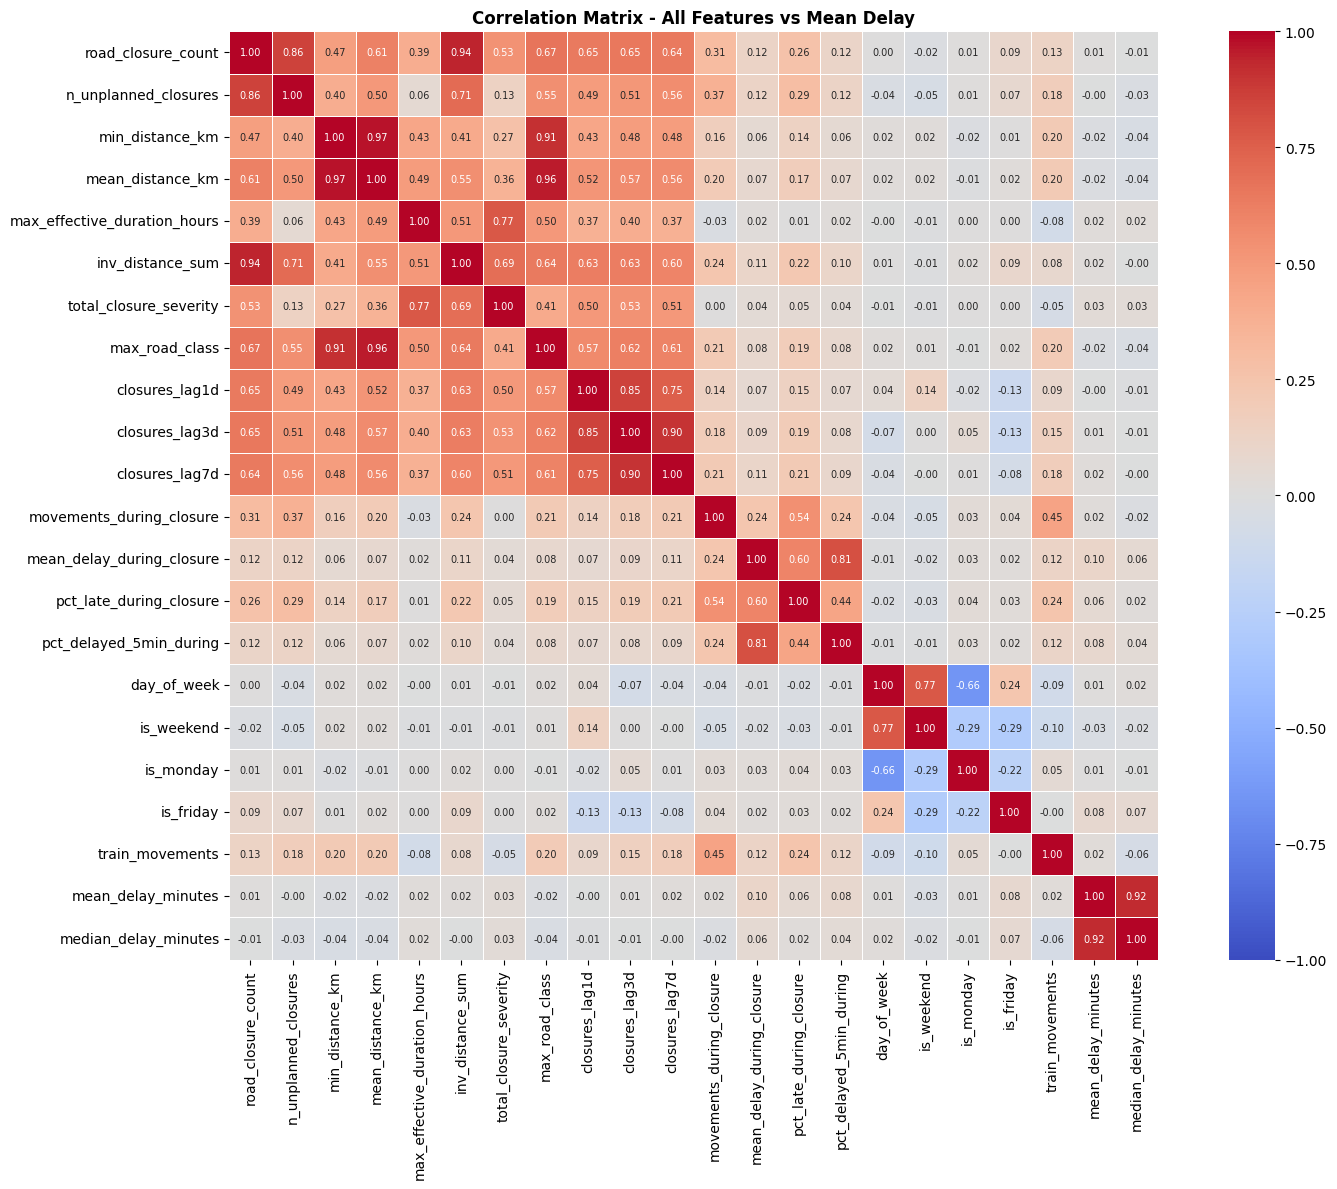


Correlation with mean_delay_minutes (sorted):
is_weekend                     -0.0340
min_distance_km                -0.0205
mean_distance_km               -0.0173
max_road_class                 -0.0156
n_unplanned_closures           -0.0035
closures_lag1d                 -0.0017
is_monday                       0.0066
day_of_week                     0.0087
closures_lag3d                  0.0109
road_closure_count              0.0115
inv_distance_sum                0.0163
movements_during_closure        0.0168
closures_lag7d                  0.0189
max_effective_duration_hours    0.0216
train_movements                 0.0248
total_closure_severity          0.0332
pct_late_during_closure         0.0577
is_friday                       0.0762
pct_delayed_5min_during         0.0841
mean_delay_during_closure       0.1024
median_delay_minutes            0.9242
Name: mean_delay_minutes, dtype: float64


In [39]:
FEATURE_COLS = [
    # Road closure features
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "mean_distance_km",
    "max_effective_duration_hours", "inv_distance_sum",
    "total_closure_severity", "max_road_class",
    # Lag features
    "closures_lag1d", "closures_lag3d", "closures_lag7d",
    # Closure-hour features
    "movements_during_closure", "mean_delay_during_closure",
    "pct_late_during_closure", "pct_delayed_5min_during",
    # Temporal features
    "day_of_week", "is_weekend", "is_monday", "is_friday",
    # Train volume
    "train_movements",
    # Targets (mean is primary; median retained from EDA 03 as secondary)
    "mean_delay_minutes", "median_delay_minutes",
]

existing = [c for c in FEATURE_COLS if c in station_day_df.columns]
corr = station_day_df[existing].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.4, vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix - All Features vs Mean Delay", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/correlation_matrix_full.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nCorrelation with mean_delay_minutes (sorted):")
if "mean_delay_minutes" in corr.columns:
    print(corr["mean_delay_minutes"].drop("mean_delay_minutes").sort_values().round(4))


## 13. EDA: Delay During vs Outside Closure Hours

Spatially filtered comparison: each station is compared against itself, looking at delay during its own nearby closure hours versus all other hours. This removes the confound of comparing different stations with different baseline delay profiles.

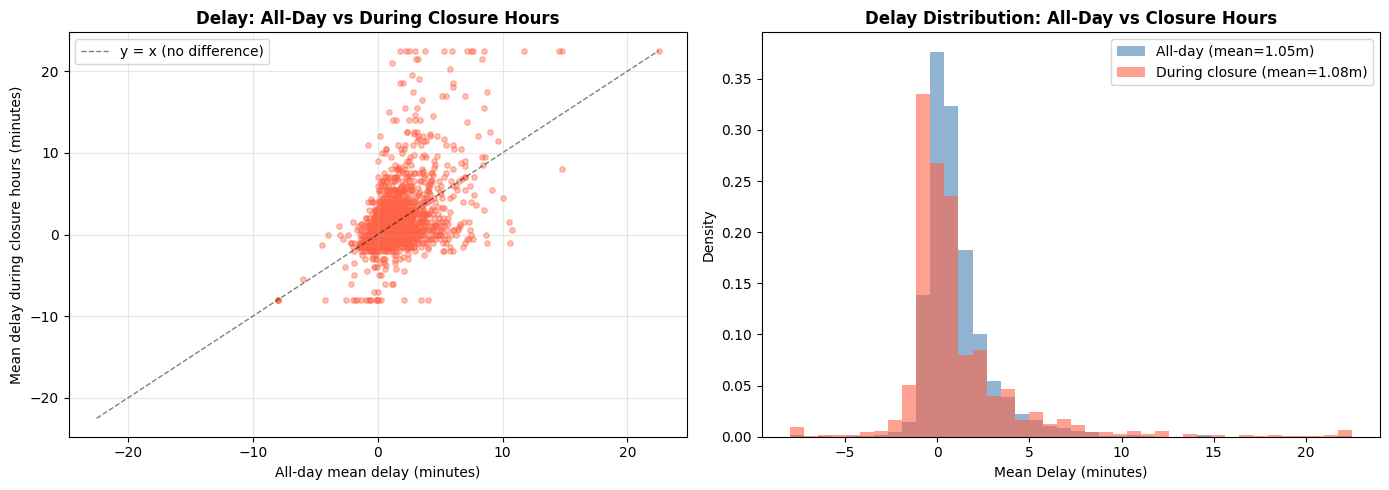

Summary: stations with movements during unplanned closure windows
  Station-days:                2,877
  All-day mean delay:          1.046 min
  Closure-hour mean delay:     1.083 min
  Closure-hour % late:         45.3%
  Closure-hour % delayed >5m:  8.3%


In [40]:
has_closure_data = station_day_df[
    station_day_df["movements_during_closure"] > 0
].copy()

if len(has_closure_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Mean delay: during vs all-day at same stations
    axes[0].scatter(
        has_closure_data["mean_delay_minutes"],
        has_closure_data["mean_delay_during_closure"],
        alpha=0.4, s=15, color="tomato"
    )
    lim = max(
        has_closure_data["mean_delay_minutes"].abs().max(),
        has_closure_data["mean_delay_during_closure"].abs().max()
    )
    axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.5,
                 label="y = x (no difference)")
    axes[0].set_xlabel("All-day mean delay (minutes)")
    axes[0].set_ylabel("Mean delay during closure hours (minutes)")
    axes[0].set_title("Delay: All-Day vs During Closure Hours", fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Distribution comparison
    axes[1].hist(
        has_closure_data["mean_delay_minutes"],
        bins=40, alpha=0.6, color="steelblue", density=True,
        label=f"All-day (mean={has_closure_data['mean_delay_minutes'].mean():.2f}m)"
    )
    axes[1].hist(
        has_closure_data["mean_delay_during_closure"],
        bins=40, alpha=0.6, color="tomato", density=True,
        label=f"During closure (mean={has_closure_data['mean_delay_during_closure'].mean():.2f}m)"
    )
    axes[1].set_xlabel("Mean Delay (minutes)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Delay Distribution: All-Day vs Closure Hours", fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("figures/eda_05/delay_during_vs_allday.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Summary table
    print("Summary: stations with movements during unplanned closure windows")
    print(f"  Station-days:                {len(has_closure_data):,}")
    print(f"  All-day mean delay:          {has_closure_data['mean_delay_minutes'].mean():.3f} min")
    print(f"  Closure-hour mean delay:     {has_closure_data['mean_delay_during_closure'].mean():.3f} min")
    print(f"  Closure-hour % late:         {has_closure_data['pct_late_during_closure'].mean()*100:.1f}%")
    print(f"  Closure-hour % delayed >5m:  {has_closure_data['pct_delayed_5min_during'].mean()*100:.1f}%")
else:
    print("No movements tagged during unplanned closure windows.")
    print("Check that unplanned_road_closures.parquet has rows and timestamps align.")

## 14. EDA: Disruption Rate by Road Class and Closure Type

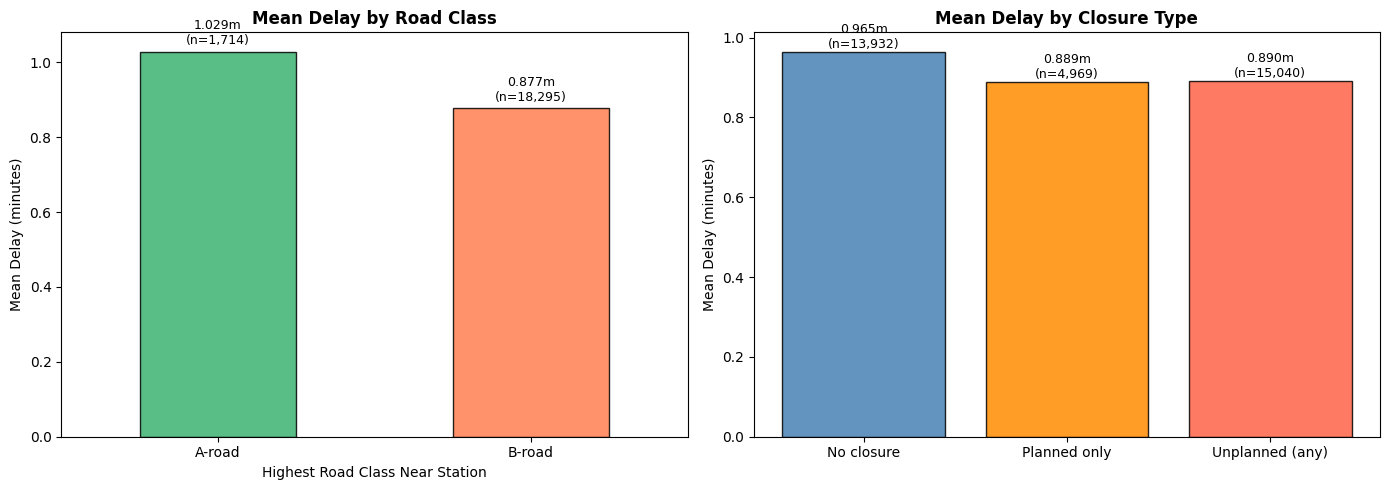

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delay by max road class at station-day
if "max_road_class" in station_day_df.columns:
    rc = (
        station_day_df[station_day_df["has_road_closure"] == 1]
        .groupby("max_road_class")["mean_delay_minutes"]
        .agg(["mean", "count"])
        .rename(index={1: "Motorway (M)", 2: "A-road", 3: "B-road"})
    )
    rc["mean"].plot(kind="bar", ax=axes[0],
                   color=["mediumseagreen", "coral", "steelblue"],
                   edgecolor="black", alpha=0.85)
    axes[0].set_title("Mean Delay by Road Class", fontweight="bold")
    axes[0].set_ylabel("Mean Delay (minutes)")
    axes[0].set_xlabel("Highest Road Class Near Station")
    axes[0].tick_params(axis="x", rotation=0)
    for i, (v, c) in enumerate(zip(rc["mean"], rc["count"])):
        axes[0].text(i, v + 0.02, f"{v:.3f}m\n(n={c:,})", ha="center", fontsize=9)

# Mean delay: no closure / planned only / unplanned - inlined boolean masks
groups = {
    "No closure":      station_day_df[
        station_day_df["has_road_closure"] == 0
    ]["mean_delay_minutes"],
    "Planned only":    station_day_df[
        (station_day_df["road_closure_count"] > station_day_df["n_unplanned_closures"])
        & (station_day_df["n_unplanned_closures"] == 0)
    ]["mean_delay_minutes"],
    "Unplanned (any)": station_day_df[
        station_day_df["n_unplanned_closures"] > 0
    ]["mean_delay_minutes"],
}
means = {k: v.mean() for k, v in groups.items()}

axes[1].bar(means.keys(), means.values(),
            color=["steelblue", "darkorange", "tomato"],
            edgecolor="black", alpha=0.85)
axes[1].set_title("Mean Delay by Closure Type", fontweight="bold")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis="x", rotation=0)
for i, (k, v) in enumerate(means.items()):
    axes[1].text(i, v + 0.01, f"{v:.3f}m\n(n={len(groups[k]):,})",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_road_class_and_type.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. EDA: Delay by Day of Week and Closure Presence

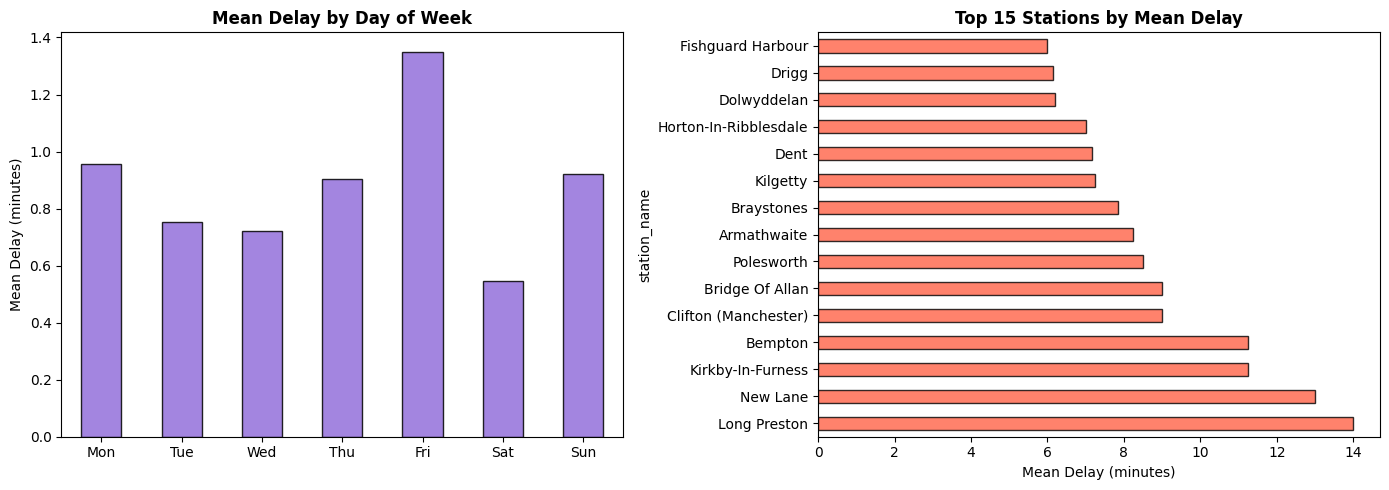

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delay by day of week - baseline temporal pattern
dow_delay = station_day_df.groupby("day_of_week")["mean_delay_minutes"].mean()
dow_delay.index = [DOW_MAP[i] for i in dow_delay.index]
dow_delay.plot(kind="bar", ax=axes[0], color="mediumpurple",
               edgecolor="black", alpha=0.85)
axes[0].set_title("Mean Delay by Day of Week", fontweight="bold")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis="x", rotation=0)

# Top 15 stations by mean delay
top_delay_stations = (
    station_day_df.groupby("station_name")["mean_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
top_delay_stations.plot(kind="barh", ax=axes[1], color="tomato",
                        edgecolor="black", alpha=0.8)
axes[1].set_title("Top 15 Stations by Mean Delay", fontweight="bold")
axes[1].set_xlabel("Mean Delay (minutes)")

plt.tight_layout()
plt.savefig("figures/eda_05/temporal_and_station_delay.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. EDA: Top Stations by Record Count

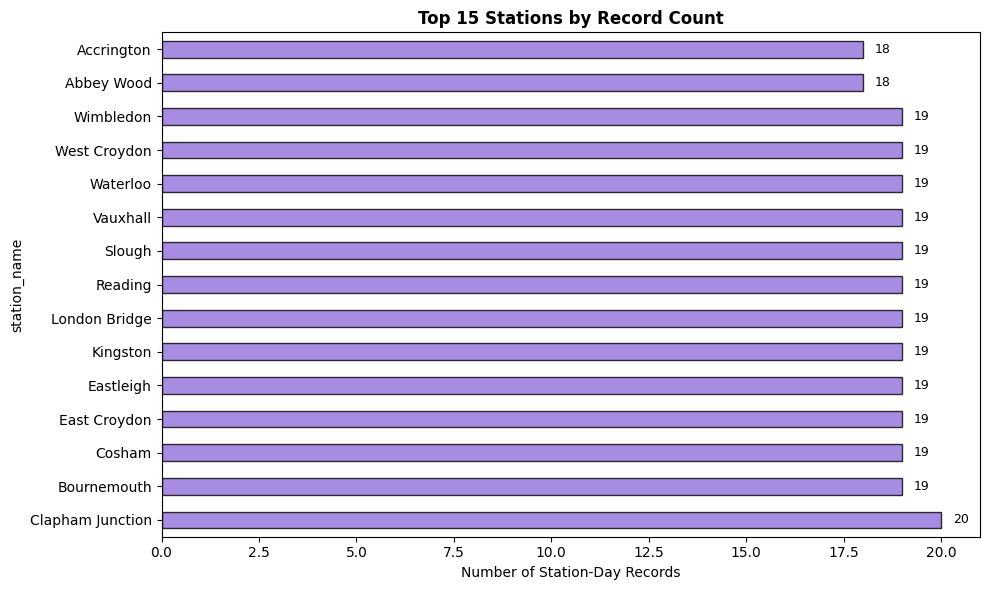

In [43]:
top_stations = station_day_df["station_name"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Station-Day Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()

## 17. Save Final Analytical Dataset

This parquet file is the primary input to `classification_modelling.ipynb` and `regression_modelling.ipynb`.

In [44]:
OUT_PATH = "./data/processed/road_station_day_dataset.parquet"
station_day_df.to_parquet(OUT_PATH, index=False)
station_day_df.to_csv("./sample_data/processed/road_station_day_dataset.csv", index=False)   

print(f"Saved: {OUT_PATH}")
print(f"Shape: {station_day_df.shape}")
print(f"\nFinal columns ({len(station_day_df.columns)}):")
print(list(station_day_df.columns))
print()
station_day_df.info()

Saved: ./data/processed/road_station_day_dataset.parquet
Shape: (33941, 35)

Final columns (35):
['station_name', 'loc_stanox', 'planned_date', 'train_movements', 'mean_delay_minutes', 'median_delay_minutes', 'max_delay_minutes', 'late_share', 'delayed_5min_share', 'severe_15min_share', 'peak_movement_share', 'station_disrupted', 'stanox', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'n_unplanned_closures', 'has_road_closure', 'movements_during_closure', 'mean_delay_during_closure', 'pct_late_during_closure', 'max_delay_during_closure', 'pct_delayed_5min_during', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d']

<class 'pandas.DataFrame'>
RangeIndex: 33941 entries, 0 to 33940
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype        
---  ------